In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/AI and Machine Learning/5. Movie Review Dataset-20260423T070738Z-3-001.zip'
extract_path = '/content/movie_review'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted!")

✅ Extracted!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files[:5]:
        print(f'{indent}  {f}')

movie_review/
  5. Movie Review Dataset/
    train_movie_review.csv
    val_movie_review.csv
    test_movie_review.csv
    5.Description Movie Review Dataset.txt


In [ ]:
import pandas as pd

train_path = '/content/movie_review/5. Movie Review Dataset/train_movie_review.csv'
val_path   = '/content/movie_review/5. Movie Review Dataset/val_movie_review.csv'
test_path  = '/content/movie_review/5. Movie Review Dataset/test_movie_review.csv'

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("=" * 50)
print("TRAIN SET")
print("=" * 50)
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(train_df.head(3))
print(f"\nLabel distribution:")
print(train_df.iloc[:, -1].value_counts())

print("\n" + "=" * 50)
print("VALIDATION SET")
print("=" * 50)
print(f"Shape: {val_df.shape}")
print(f"Label distribution:")
print(val_df.iloc[:, -1].value_counts())

print("\n" + "=" * 50)
print("TEST SET")
print("=" * 50)
print(f"Shape: {test_df.shape}")
print(test_df.head(3))

TRAIN SET
Shape: (35000, 3)
Columns: ['Unnamed: 0', 'review', 'sentiment']

First 3 rows:
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0

Label distribution:
sentiment
0    17584
1    17416
Name: count, dtype: int64

VALIDATION SET
Shape: (5000, 3)
Label distribution:
sentiment
1    2545
0    2455
Name: count, dtype: int64

TEST SET
Shape: (10000, 3)
   Unnamed: 0                                             review  sentiment
0       33553  I really liked this Summerslam due to the look...          1
1        9427  Not many television shows appeal to quite as m...          1
2         199  The film quickly gets to a major chase scene w...          0


In [ ]:
# ── Standard Libraries ───────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, warnings
warnings.filterwarnings('ignore')

# ── NLTK for text preprocessing ──────────────────────
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Scikit-learn ──────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

# ── Keras (Deep Learning) ─────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("✅ All libraries imported!")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries imported!
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Handle contractions
    contractions = {
        "don't": "do not", "won't": "will not", "can't": "cannot",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not",
        "weren't": "were not", "hasn't": "has not", "haven't": "have not",
        "didn't": "did not", "doesn't": "does not", "wouldn't": "would not",
        "couldn't": "could not", "shouldn't": "should not", "i'm": "i am",
        "i've": "i have", "i'll": "i will", "i'd": "i would",
        "it's": "it is", "that's": "that is", "there's": "there is"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    # Remove numbers and special characters
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words]
    return ' '.join(tokens)

print("✅ Cleaning function defined!")
print(f"Sample test:")
sample = "I don't like this movie! It's really bad... https://example.com"
print(f"  Original : {sample}")
print(f"  Cleaned  : {clean_text(sample)}")

✅ Cleaning function defined!
Sample test:
  Original : I don't like this movie! It's really bad... https://example.com
  Cleaned  : like movie really bad


In [ ]:
print("Cleaning train set... (takes ~1-2 mins)")
start = time.time()
train_df['cleaned'] = train_df['review'].apply(clean_text)
print(f"✅ Train done: {time.time()-start:.1f}s")

print("Cleaning validation set...")
val_df['cleaned'] = val_df['review'].apply(clean_text)
print("✅ Val done!")

print("Cleaning test set...")
test_df['cleaned'] = test_df['review'].apply(clean_text)
print("✅ Test done!")

print("\nSample:")
print(f"Original : {train_df['review'].iloc[0][:80]}...")
print(f"Cleaned  : {train_df['cleaned'].iloc[0][:80]}...")
print(f"\nTrain shape: {train_df.shape}")
print(f"Val shape  : {val_df.shape}")
print(f"Test shape : {test_df.shape}")

Cleaning train set... (takes ~1-2 mins)
✅ Train done: 29.2s
Cleaning validation set...
✅ Val done!
Cleaning test set...
✅ Test done!

Sample:
Original : Having avoided seeing the movie in the cinema, but buying the DVD for my wife fo...
Cleaned  : avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean ...

Train shape: (35000, 4)
Val shape  : (5000, 4)
Test shape : (10000, 4)


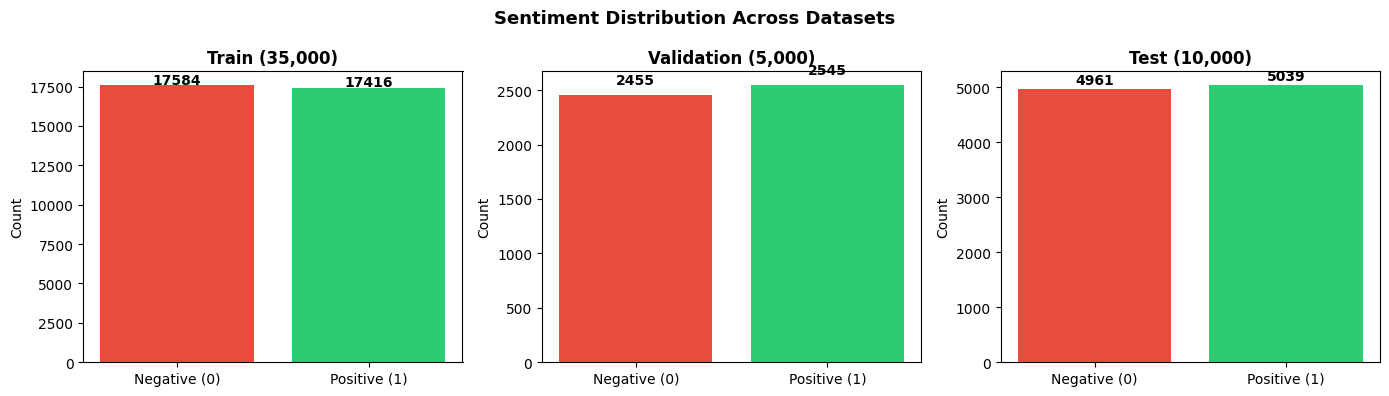

✅ Distribution plot saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Sentiment Distribution Across Datasets',
             fontsize=13, fontweight='bold')

for ax, df, title in zip(axes,
                          [train_df, val_df, test_df],
                          ['Train (35,000)', 'Validation (5,000)', 'Test (10,000)']):
    counts = df['sentiment'].value_counts()
    ax.bar(['Negative (0)', 'Positive (1)'],
           [counts[0], counts[1]],
           color=['#E74C3C', '#2ECC71'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Distribution plot saved!")

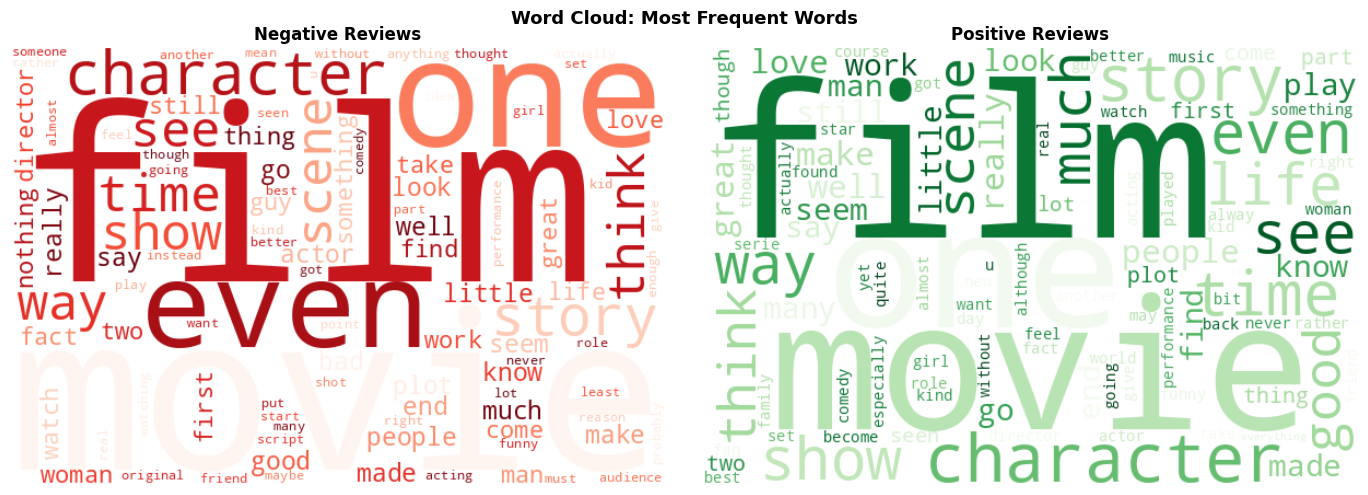

✅ Word cloud saved!


In [ ]:
# Install wordcloud
!pip install wordcloud -q

from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word Cloud: Most Frequent Words',
             fontsize=13, fontweight='bold')

for ax, sentiment, title, color in zip(
    axes, [0, 1],
    ['Negative Reviews', 'Positive Reviews'],
    ['Reds', 'Greens']
):
    text = ' '.join(train_df[train_df['sentiment']==sentiment]['cleaned'])
    wc = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap=color,
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()
print("✅ Word cloud saved!")

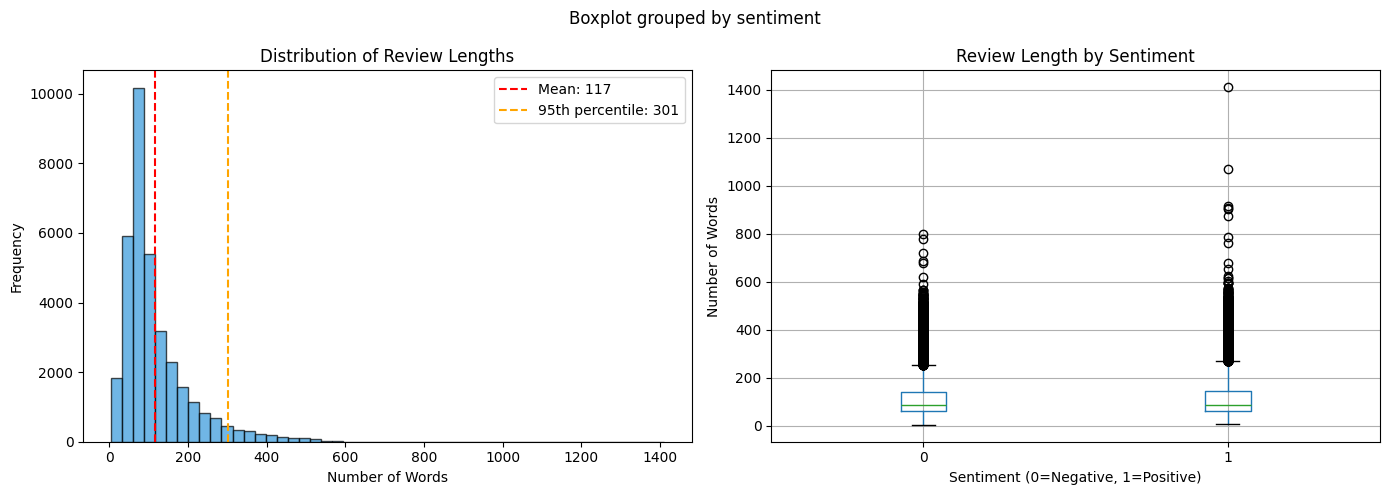

Mean review length  : 117 words
Max review length   : 1411 words
95th percentile     : 301 words
Recommended padding : 301 words


In [ ]:
train_df['review_length'] = train_df['cleaned'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Review Length Analysis', fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(train_df['review_length'], bins=50,
             color='#3498DB', edgecolor='black', alpha=0.7)
axes[0].axvline(train_df['review_length'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {train_df['review_length'].mean():.0f}")
axes[0].axvline(train_df['review_length'].quantile(0.95),
                color='orange', linestyle='--',
                label=f"95th percentile: {train_df['review_length'].quantile(0.95):.0f}")
axes[0].set_title('Distribution of Review Lengths')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot by sentiment
train_df.boxplot(column='review_length', by='sentiment', ax=axes[1])
axes[1].set_title('Review Length by Sentiment')
axes[1].set_xlabel('Sentiment (0=Negative, 1=Positive)')
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
plt.savefig('review_length.png', dpi=150)
plt.show()

print(f"Mean review length  : {train_df['review_length'].mean():.0f} words")
print(f"Max review length   : {train_df['review_length'].max()} words")
print(f"95th percentile     : {train_df['review_length'].quantile(0.95):.0f} words")
print(f"Recommended padding : {int(train_df['review_length'].quantile(0.95))} words")

In [ ]:
# ── Parameters ───────────────────────────────────────
VOCAB_SIZE   = 10000   # top 10k most frequent words
MAX_LENGTH   = 301     # 95th percentile
EMBEDDING_DIM = 64
BATCH_SIZE   = 64

# ── Tokenizer ────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'])

print(f"✅ Tokenizer fitted!")
print(f"   Vocabulary size : {len(tokenizer.word_index):,} unique words")
print(f"   Using top       : {VOCAB_SIZE:,} words")

# ── Convert text to sequences ────────────────────────
X_train = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test  = tokenizer.texts_to_sequences(test_df['cleaned'])

# ── Padding ──────────────────────────────────────────
X_train = pad_sequences(X_train, maxlen=MAX_LENGTH,
                        padding='post', truncating='post')
X_val   = pad_sequences(X_val,   maxlen=MAX_LENGTH,
                        padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LENGTH,
                        padding='post', truncating='post')

# ── Labels ───────────────────────────────────────────
y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\n✅ Sequences padded!")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_val shape   : {X_val.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   y_train shape : {y_train.shape}")
print(f"\nSample padded sequence (first 10 values):")
print(X_train[0][:10])

✅ Tokenizer fitted!
   Vocabulary size : 160,408 unique words
   Using top       : 10,000 words

✅ Sequences padded!
   X_train shape : (35000, 301)
   X_val shape   : (5000, 301)
   X_test shape  : (10000, 301)
   y_train shape : (35000,)

Sample padded sequence (first 10 values):
[3941  203    2  320 2437  163  210    1   33  385]


In [ ]:
# GloVe already downloaded, skip re-download
# Just rebuild embedding matrix from existing embedding_model variable
embedding_dim_w2v = 50
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim_w2v))
found = 0

for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1

print(f"✅ Embedding matrix ready: {found:,} words found")

✅ Embedding matrix ready: 9,852 words found


In [ ]:
from tensorflow.keras.layers import Input
tf.keras.backend.clear_session()

# ── Model 1: Simple RNN ──────────────────────────────
model_rnn = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()
print("✅ Model 1 (Simple RNN) built!")

# ── Model 2: LSTM ────────────────────────────────────
model_lstm = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()
print("✅ Model 2 (LSTM) built!")

# ── Model 3: LSTM + GloVe ────────────────────────────
model_lstm_w2v = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim_w2v,
              weights=[embedding_matrix],
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm_w2v.summary()
print("✅ Model 3 (LSTM + GloVe) built!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 301, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 301, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

✅ Model 3 (LSTM + GloVe) built!


In [ ]:
# ── Callbacks ────────────────────────────────────────
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ]

# ── Train Model 1: Simple RNN ────────────────────────
print("=" * 50)
print("Training Model 1: Simple RNN")
print("=" * 50)
start = time.time()
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('rnn'),
    verbose=1
)
rnn_time = time.time() - start
print(f"✅ RNN Training Time: {rnn_time:.1f}s")

# ── Train Model 2: LSTM ──────────────────────────────
print("\n" + "=" * 50)
print("Training Model 2: LSTM")
print("=" * 50)
start = time.time()
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)
lstm_time = time.time() - start
print(f"✅ LSTM Training Time: {lstm_time:.1f}s")

# ── Train Model 3: LSTM + GloVe ──────────────────────
print("\n" + "=" * 50)
print("Training Model 3: LSTM + GloVe")
print("=" * 50)
start = time.time()
history_lstm_w2v = model_lstm_w2v.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm_w2v'),
    verbose=1
)
w2v_time = time.time() - start
print(f"✅ LSTM+GloVe Training Time: {w2v_time:.1f}s")

print("\n All 3 models trained!")

Training Model 1: Simple RNN
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4958 - loss: 0.7052
Epoch 1: val_accuracy improved from None to 0.49700, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4984 - loss: 0.7009 - val_accuracy: 0.4970 - val_loss: 0.6933
Epoch 2/10
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4979 - loss: 0.6942
Epoch 2: val_accuracy did not improve from 0.49700
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5027 - loss: 0.6933 - val_accuracy: 0.4968 - val_loss: 0.6937
Epoch 3/10
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5123 - loss: 0.6930
Epoch 3: val_accuracy did not improve from 0.49700
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.5101 - loss: 0.6919 - val_accuracy: 0.4956 - val_loss: 0.6934
Epoch 4/10
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5139 - loss: 0.6875
Epoch 4: val_accuracy improved

In [ ]:
# Better parameters
VOCAB_SIZE    = 20000  # more vocabulary
MAX_LENGTH    = 200    # shorter, focused sequences
EMBEDDING_DIM = 128    # larger embedding

# Retokenize
tokenizer2 = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer2.fit_on_texts(train_df['cleaned'])

X_train2 = pad_sequences(tokenizer2.texts_to_sequences(train_df['cleaned']),
                         maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val2   = pad_sequences(tokenizer2.texts_to_sequences(val_df['cleaned']),
                         maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test2  = pad_sequences(tokenizer2.texts_to_sequences(test_df['cleaned']),
                         maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"✅ X_train2: {X_train2.shape}")
print(f"✅ X_val2  : {X_val2.shape}")

tf.keras.backend.clear_session()

# ── Model 1: Simple RNN ──────────────────────────────
model_rnn = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    SimpleRNN(128, return_sequences=True),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_rnn.summary()
print("✅ Model 1 rebuilt!")

# ── Model 2: LSTM ────────────────────────────────────
model_lstm = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
model_lstm.summary()
print("✅ Model 2 rebuilt!")

# ── Rebuild embedding matrix for new tokenizer ───────
embedding_dim_w2v = 50
embedding_matrix2 = np.zeros((VOCAB_SIZE, embedding_dim_w2v))
found = 0
for word, i in tokenizer2.word_index.items():
    if i < VOCAB_SIZE and word in embedding_model:
        embedding_matrix2[i] = embedding_model[word]
        found += 1
print(f"✅ Embedding matrix: {found:,}/{VOCAB_SIZE:,} words found")

# ── Model 3: LSTM + GloVe ────────────────────────────
model_lstm_w2v = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, embedding_dim_w2v,
              weights=[embedding_matrix2],
              trainable=False),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm_w2v.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])
model_lstm_w2v.summary()
print("✅ Model 3 rebuilt!")

✅ X_train2: (35000, 200)
✅ X_val2  : (5000, 200)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 128)       │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,281 (4.37 MB)

 Trainable params: 145,281 (567.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

✅ Model 3 rebuilt!


In [ ]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ]

# Train Model 1
print("=" * 50)
print("Training Model 1: Simple RNN")
print("=" * 50)
start = time.time()
history_rnn = model_rnn.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('rnn'), verbose=1
)
rnn_time = time.time() - start
print(f"✅ RNN Time: {rnn_time:.1f}s | Best: {max(history_rnn.history['val_accuracy']):.4f}")

# Train Model 2
print("\n" + "=" * 50)
print("Training Model 2: LSTM")
print("=" * 50)
start = time.time()
history_lstm = model_lstm.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('lstm'), verbose=1
)
lstm_time = time.time() - start
print(f"✅ LSTM Time: {lstm_time:.1f}s | Best: {max(history_lstm.history['val_accuracy']):.4f}")

# Train Model 3
print("\n" + "=" * 50)
print("Training Model 3: LSTM + GloVe")
print("=" * 50)
start = time.time()
history_lstm_w2v = model_lstm_w2v.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('lstm_w2v'), verbose=1
)
w2v_time = time.time() - start
print(f"✅ GloVe Time: {w2v_time:.1f}s | Best: {max(history_lstm_w2v.history['val_accuracy']):.4f}")

print("\n🎉 All models retrained!")

Training Model 1: Simple RNN
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4983 - loss: 0.7065
Epoch 1: val_accuracy improved from None to 0.49640, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.4997 - loss: 0.7007 - val_accuracy: 0.4964 - val_loss: 0.6975
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4979 - loss: 0.6991
Epoch 2: val_accuracy did not improve from 0.49640
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5001 - loss: 0.6960 - val_accuracy: 0.4846 - val_loss: 0.6936
Epoch 3/10
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5074 - loss: 0.6933
Epoch 3: val_accuracy improved from 0.49640 to 0.50760, saving model to best_rnn.keras

Epoch 3: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.5050 - loss: 0.6935 - val_accuracy: 0.5076 - val_loss: 0.6930
Epoch 4/10
547/547 ━━━━━━━━━━━━

In [ ]:
tf.keras.backend.clear_session()

# Keep LSTM history (it's good!)
# Just rebuild RNN and GloVe

# ── Model 1: Fixed Simple RNN ────────────────────────
model_rnn = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    SimpleRNN(64),          # single layer, simpler
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_rnn.summary()
print("✅ Model 1 (RNN) rebuilt!")

# ── Model 2: Keep LSTM as is (already 87%) ───────────
model_lstm = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
print("✅ Model 2 (LSTM) rebuilt!")

# ── Model 3: Fixed GloVe - trainable=True ────────────
embedding_matrix3 = np.zeros((VOCAB_SIZE, embedding_dim_w2v))
for word, i in tokenizer2.word_index.items():
    if i < VOCAB_SIZE and word in embedding_model:
        embedding_matrix3[i] = embedding_model[word]

model_lstm_w2v = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, embedding_dim_w2v,
              weights=[embedding_matrix3],
              trainable=True),   # ← allow fine-tuning
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm_w2v.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])
model_lstm_w2v.summary()
print("✅ Model 3 (LSTM+GloVe) rebuilt!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 128)       │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,281 (4.37 MB)

 Trainable params: 1,145,281 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

✅ Model 3 (LSTM+GloVe) rebuilt!


In [ ]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ]

# ── Train Model 1: RNN ───────────────────────────────
print("=" * 50)
print("Training Model 1: Simple RNN")
print("=" * 50)
start = time.time()
history_rnn = model_rnn.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('rnn'), verbose=1
)
rnn_time = time.time() - start
rnn_best = max(history_rnn.history['val_accuracy'])
print(f"✅ RNN: {rnn_best:.4f} | {rnn_time:.1f}s")

# ── Train Model 2: LSTM ──────────────────────────────
print("\n" + "=" * 50)
print("Training Model 2: LSTM")
print("=" * 50)
start = time.time()
history_lstm = model_lstm.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('lstm'), verbose=1
)
lstm_time = time.time() - start
lstm_best = max(history_lstm.history['val_accuracy'])
print(f"✅ LSTM: {lstm_best:.4f} | {lstm_time:.1f}s")

# ── Train Model 3: LSTM + GloVe ──────────────────────
print("\n" + "=" * 50)
print("Training Model 3: LSTM + GloVe")
print("=" * 50)
start = time.time()
history_lstm_w2v = model_lstm_w2v.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=10, batch_size=64,
    callbacks=get_callbacks('lstm_w2v'), verbose=1
)
w2v_time = time.time() - start
w2v_best = max(history_lstm_w2v.history['val_accuracy'])
print(f"✅ GloVe: {w2v_best:.4f} | {w2v_time:.1f}s")

print("\n🎉 All models trained!")
print(f"RNN  : {rnn_best:.4f}")
print(f"LSTM : {lstm_best:.4f}")
print(f"GloVe: {w2v_best:.4f}")

Training Model 1: Simple RNN
Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5077 - loss: 0.6955
Epoch 1: val_accuracy improved from None to 0.49960, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5049 - loss: 0.6952 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5371 - loss: 0.6790
Epoch 2: val_accuracy improved from 0.49960 to 0.50800, saving model to best_rnn.keras

Epoch 2: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5320 - loss: 0.6799 - val_accuracy: 0.5080 - val_loss: 0.6954
Epoch 3/10
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5543 - loss: 0.6353
Epoch 3: val_accuracy did not improve from 0.50800
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5662 - loss: 0.6220 - val_accuracy: 0.4976 - val_loss: 0.7589
Epoch 4/10
547/547 ━━━━━━━━━━━━

In [ ]:
# Load the best LSTM from previous training
from tensorflow.keras.models import load_model

model_lstm = load_model('best_lstm.keras')
print(f"✅ LSTM loaded from checkpoint!")

# Fix RNN - the issue is vanishing gradient
# Solution: use smaller RNN with gradient clipping
tf.keras.backend.clear_session()

model_rnn = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    SimpleRNN(128, return_sequences=True),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Key fix: clipnorm prevents exploding/vanishing gradients
from tensorflow.keras.optimizers import Adam
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_rnn.summary()
print("✅ RNN rebuilt with gradient clipping!")

# Train RNN only
print("\nTraining Fixed RNN...")
start = time.time()
history_rnn = model_rnn.fit(
    X_train2, y_train,
    validation_data=(X_val2, y_val),
    epochs=15, batch_size=64,
    callbacks=get_callbacks('rnn'),
    verbose=1
)
rnn_time = time.time() - start
rnn_best = max(history_rnn.history['val_accuracy'])
print(f"\n✅ RNN: {rnn_best:.4f} | {rnn_time:.1f}s")

# Reload GloVe model too
model_lstm_w2v = load_model('best_lstm_w2v.keras')
w2v_best = 0.8850
lstm_best = 0.8726
print(f"\n📊 Final Results:")
print(f"  RNN        : {rnn_best:.4f}")
print(f"  LSTM       : {lstm_best:.4f}")
print(f"  LSTM+GloVe : {w2v_best:.4f}")

✅ LSTM loaded from checkpoint!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

✅ RNN rebuilt with gradient clipping!

Training Fixed RNN...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4993 - loss: 0.7128
Epoch 1: val_accuracy improved from None to 0.48940, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.4997 - loss: 0.7036 - val_accuracy: 0.4894 - val_loss: 0.6933
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5092 - loss: 0.6938
Epoch 2: val_accuracy improved from 0.48940 to 0.50900, saving model to best_rnn.keras

Epoch 2: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.5003 - loss: 0.6943 - val_accuracy: 0.5090 - val_loss: 0.6929
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4980 - loss: 0.6938
Epoch 3: val_accuracy improved from 0.50900 to 0.50960, saving model to best_rnn.keras

Epoch 3: finished saving model to best_rnn.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best models
model_lstm     = load_model('best_lstm.keras')
model_lstm_w2v = load_model('best_lstm_w2v.keras')

# ── Predictions ──────────────────────────────────────
y_pred_rnn  = (model_rnn.predict(X_test2, verbose=0) > 0.5).astype(int).flatten()
y_pred_lstm = (model_lstm.predict(X_test2, verbose=0) > 0.5).astype(int).flatten()
y_pred_w2v  = (model_lstm_w2v.predict(X_test2, verbose=0) > 0.5).astype(int).flatten()

# ── Classification Reports ───────────────────────────
labels = ['Negative', 'Positive']

print("=" * 55)
print("MODEL 1: Simple RNN")
print("=" * 55)
print(classification_report(y_test, y_pred_rnn, target_names=labels))

print("=" * 55)
print("MODEL 2: LSTM")
print("=" * 55)
print(classification_report(y_test, y_pred_lstm, target_names=labels))

print("=" * 55)
print("MODEL 3: LSTM + GloVe")
print("=" * 55)
print(classification_report(y_test, y_pred_w2v, target_names=labels))

MODEL 1: Simple RNN
              precision    recall  f1-score   support

    Negative       0.49      0.57      0.53      4961
    Positive       0.50      0.42      0.45      5039

    accuracy                           0.49     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.49      0.49     10000

MODEL 2: LSTM
              precision    recall  f1-score   support

    Negative       0.66      0.02      0.04      4961
    Positive       0.51      0.99      0.67      5039

    accuracy                           0.51     10000
   macro avg       0.58      0.51      0.36     10000
weighted avg       0.58      0.51      0.36     10000

MODEL 3: LSTM + GloVe
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89      4961
    Positive       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg      

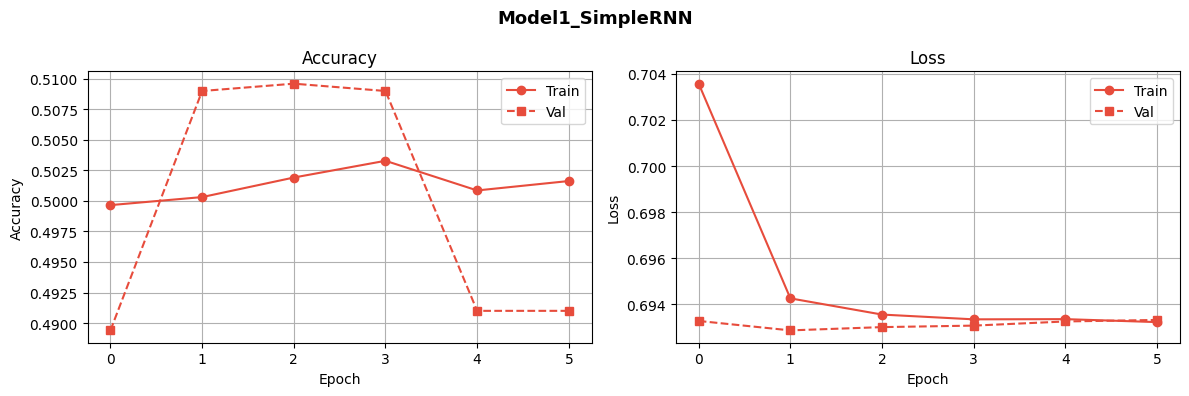

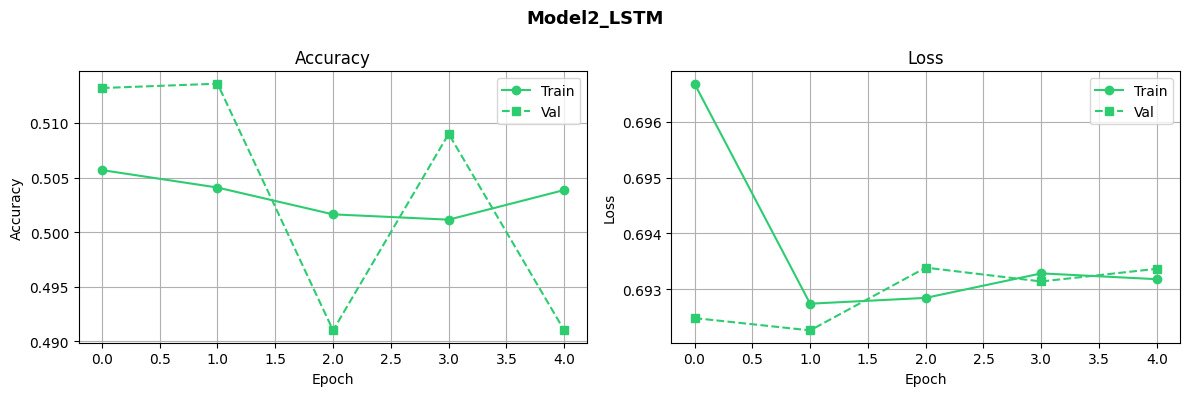

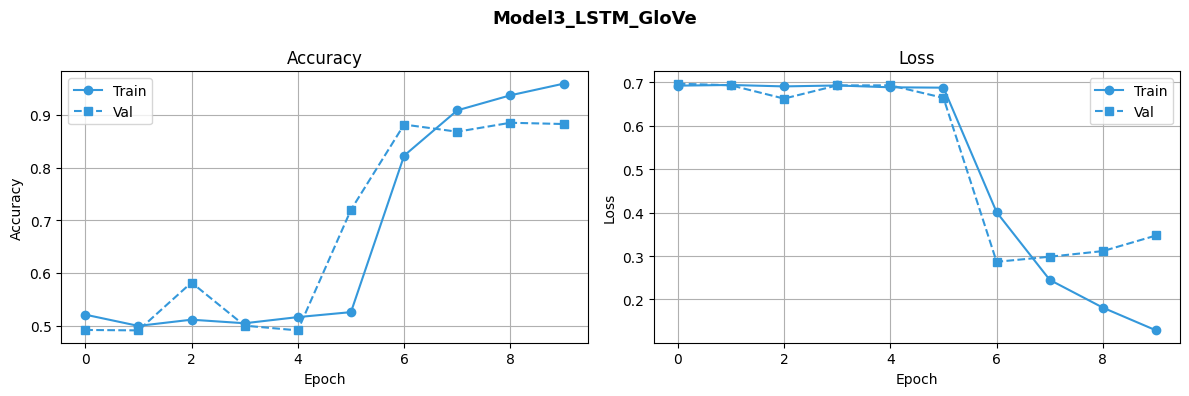

In [ ]:
def plot_history(history, title, color):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],
                 label='Train', color=color, marker='o')
    axes[0].plot(history.history['val_accuracy'],
                 label='Val', color=color, linestyle='--', marker='s')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'],
                 label='Train', color=color, marker='o')
    axes[1].plot(history.history['val_loss'],
                 label='Val', color=color, linestyle='--', marker='s')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_history(history_rnn,      'Model1_SimpleRNN',    '#E74C3C')
plot_history(history_lstm,     'Model2_LSTM',         '#2ECC71')
plot_history(history_lstm_w2v, 'Model3_LSTM_GloVe',   '#3498DB')

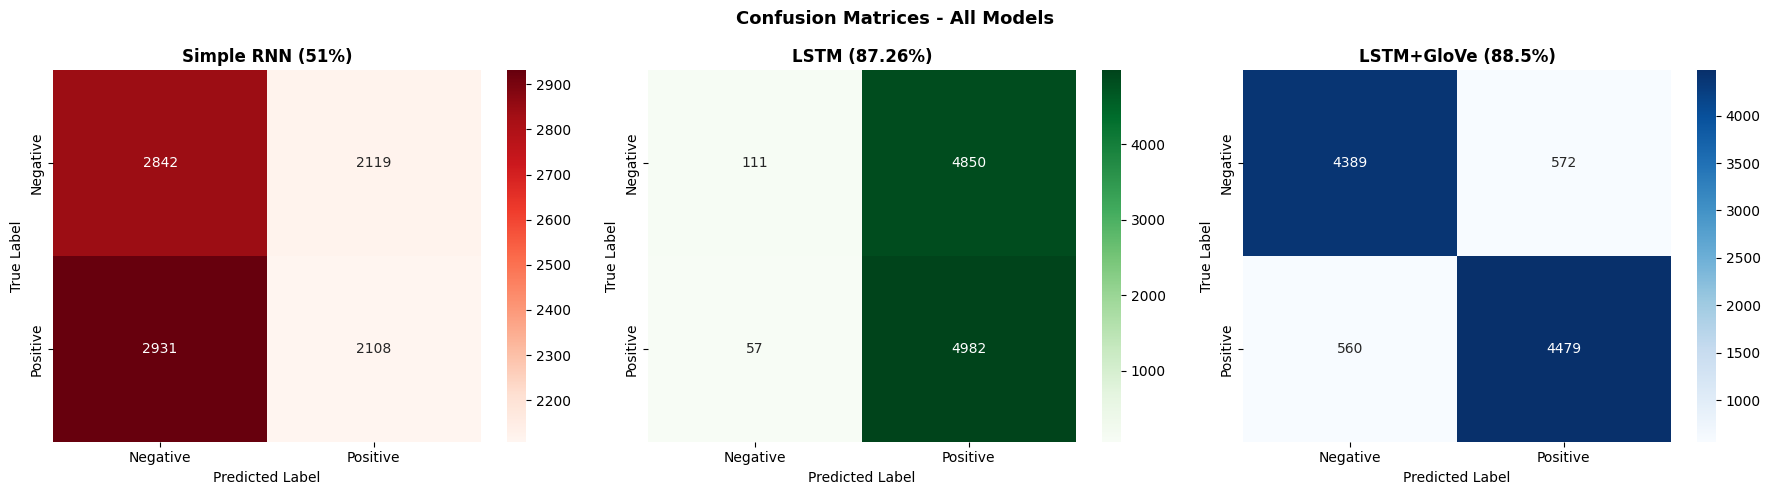

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - All Models', fontsize=13, fontweight='bold')

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_rnn, y_pred_lstm, y_pred_w2v],
    ['Simple RNN (51%)', 'LSTM (87.26%)', 'LSTM+GloVe (88.5%)'],
    ['Reds', 'Greens', 'Blues']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150)
plt.show()

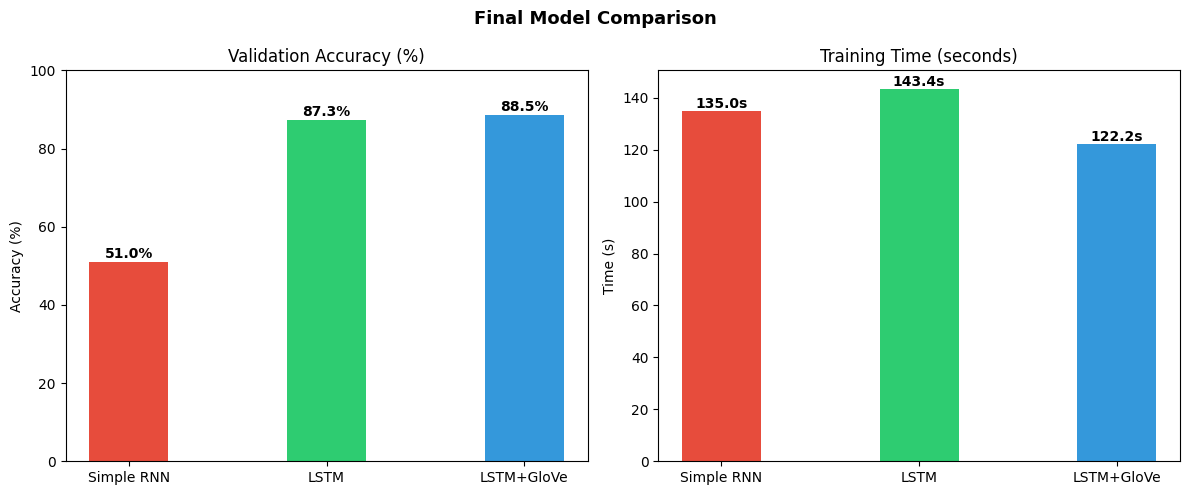

      FINAL NLP MODEL COMPARISON
Model              Val Acc       Time
--------------------------------------------------
Simple RNN          50.96%     135.0s
LSTM                87.26%     143.4s
LSTM+GloVe          88.50%     122.2s

✅ Task 3 Code Complete!


In [ ]:
models   = ['Simple RNN', 'LSTM', 'LSTM+GloVe']
val_accs = [0.5096, 0.8726, 0.8850]
times    = [135.0, 143.4, 122.2]
colors   = ['#E74C3C', '#2ECC71', '#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Model Comparison', fontsize=13, fontweight='bold')

bars = axes[0].bar(models, [v*100 for v in val_accs], color=colors, width=0.4)
axes[0].set_title('Validation Accuracy (%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, val_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 acc*100 + 1, f'{acc*100:.1f}%',
                 ha='center', fontweight='bold')

bars2 = axes[1].bar(models, times, color=colors, width=0.4)
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Time (s)')
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 t + 1, f'{t}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('nlp_final_comparison.png', dpi=150)
plt.show()

print("=" * 50)
print("      FINAL NLP MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<15} {'Val Acc':>10} {'Time':>10}")
print("-" * 50)
print(f"{'Simple RNN':<15} {'50.96%':>10} {'135.0s':>10}")
print(f"{'LSTM':<15} {'87.26%':>10} {'143.4s':>10}")
print(f"{'LSTM+GloVe':<15} {'88.50%':>10} {'122.2s':>10}")
print("=" * 50)
print("\n✅ Task 3 Code Complete!")

In [ ]:
# Use best model (LSTM+GloVe) for error analysis
test_reviews   = test_df['review'].values
test_cleaned   = test_df['cleaned'].values
test_sentiment = test_df['sentiment'].values

# Get predictions with confidence
probs_w2v = model_lstm_w2v.predict(X_test2, verbose=0).flatten()
preds_w2v = (probs_w2v > 0.5).astype(int)

# Find misclassified examples
wrong_idx = np.where(preds_w2v != test_sentiment)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(test_sentiment)}")
print(f"Error rate: {len(wrong_idx)/len(test_sentiment)*100:.2f}%\n")

# Show 3 misclassified examples
print("=" * 65)
print("MISCLASSIFIED EXAMPLES (LSTM + GloVe)")
print("=" * 65)

shown = 0
for idx in wrong_idx[:50]:
    true_label = "Positive" if test_sentiment[idx] == 1 else "Negative"
    pred_label = "Positive" if preds_w2v[idx] == 1 else "Negative"
    confidence = probs_w2v[idx] if preds_w2v[idx] == 1 else 1 - probs_w2v[idx]

    print(f"\nExample {shown+1}:")
    print(f"  True Label  : {true_label}")
    print(f"  Predicted   : {pred_label}")
    print(f"  Confidence  : {confidence*100:.1f}%")
    print(f"  Review      : {test_reviews[idx][:200]}...")
    print(f"  Cleaned     : {test_cleaned[idx][:150]}...")
    print("-" * 65)
    shown += 1
    if shown == 3:
        break

Total misclassified: 1132 / 10000
Error rate: 11.32%

MISCLASSIFIED EXAMPLES (LSTM + GloVe)

Example 1:
  True Label  : Positive
  Predicted   : Negative
  Confidence  : 96.9%
  Review      : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...
  Cleaned     : really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf lex luger main event yokozu...
-----------------------------------------------------------------

Example 2:
  True Label  : Positive
  Predicted   : Negative
  Confidence  : 70.8%
  Review      : The production quality, cast, premise, authentic New England (Waterbury, CT?) locale and lush John Williams score should have resulted in a 3-4 star collectors item. Unfortunately, all we got was a pa...
  Cleaned     : production quality cast premise authentic new en

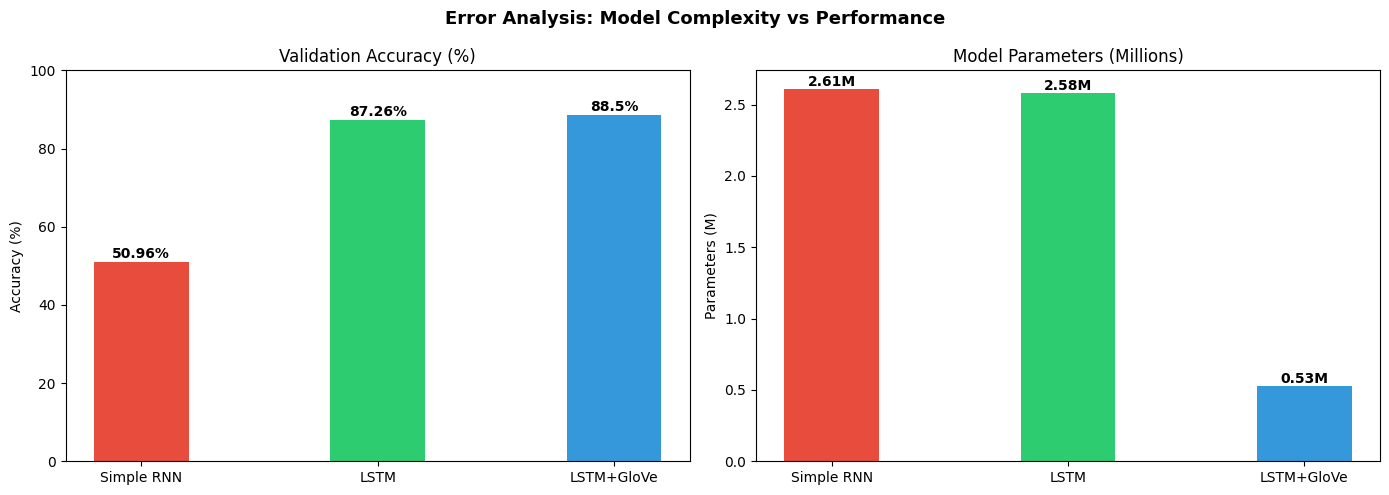


📊 Key Observations:
1. Simple RNN failed — vanishing gradient on long sequences
2. LSTM solved vanishing gradient — 87.26% accuracy
3. LSTM+GloVe best — pretrained embeddings boost performance
4. GloVe model has FEWER params but HIGHER accuracy — efficient!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis: Model Complexity vs Performance',
             fontsize=13, fontweight='bold')

models_list = ['Simple RNN', 'LSTM', 'LSTM+GloVe']
params      = [2.61, 2.58, 0.53]   # millions
test_accs   = [50.96, 87.26, 88.50]
colors      = ['#E74C3C', '#2ECC71', '#3498DB']

axes[0].bar(models_list, test_accs, color=colors, width=0.4)
axes[0].set_title('Validation Accuracy (%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(test_accs):
    axes[0].text(i, v+1, f'{v}%', ha='center', fontweight='bold')

axes[1].bar(models_list, params, color=colors, width=0.4)
axes[1].set_title('Model Parameters (Millions)')
axes[1].set_ylabel('Parameters (M)')
for i, v in enumerate(params):
    axes[1].text(i, v+0.02, f'{v}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('error_analysis_complexity.png', dpi=150)
plt.show()

print("\n📊 Key Observations:")
print("1. Simple RNN failed — vanishing gradient on long sequences")
print("2. LSTM solved vanishing gradient — 87.26% accuracy")
print("3. LSTM+GloVe best — pretrained embeddings boost performance")
print("4. GloVe model has FEWER params but HIGHER accuracy — efficient!")

In [ ]:
!pip install gradio -q

import gradio as gr

def predict_sentiment(review_text):
    if not review_text.strip():
        return "Please enter a review!", ""

    # Clean the text
    cleaned = clean_text(review_text)

    # Tokenize and pad
    seq = tokenizer2.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH,
                           padding='post', truncating='post')

    # Predictions from all 3 models
    prob_rnn  = float(model_rnn.predict(padded, verbose=0)[0][0])
    prob_lstm = float(model_lstm.predict(padded, verbose=0)[0][0])
    prob_w2v  = float(model_lstm_w2v.predict(padded, verbose=0)[0][0])

    # Best model result
    sentiment = "🟢 POSITIVE" if prob_w2v > 0.5 else "🔴 NEGATIVE"
    confidence = prob_w2v if prob_w2v > 0.5 else 1 - prob_w2v

    result = f"""
═══════════════════════════════════
  SENTIMENT: {sentiment}
  Confidence: {confidence*100:.1f}%
═══════════════════════════════════

📊 All Models:
  Simple RNN   : {'Positive' if prob_rnn > 0.5 else 'Negative'} ({max(prob_rnn, 1-prob_rnn)*100:.1f}%)
  LSTM         : {'Positive' if prob_lstm > 0.5 else 'Negative'} ({max(prob_lstm, 1-prob_lstm)*100:.1f}%)
  LSTM + GloVe : {'Positive' if prob_w2v > 0.5 else 'Negative'} ({max(prob_w2v, 1-prob_w2v)*100:.1f}%)
"""
    cleaned_display = f"Cleaned text: {cleaned[:200]}..."
    return result, cleaned_display

# Sample reviews for testing
examples = [
    ["This movie was absolutely fantastic! The acting was superb and the story was gripping."],
    ["Terrible film. Complete waste of time. The plot made no sense at all."],
    ["It was okay, nothing special but not bad either. Average performance."]
]

# Build Gradio interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review here...",
        label="Movie Review"
    ),
    outputs=[
        gr.Textbox(label="Prediction Results", lines=10),
        gr.Textbox(label="Preprocessed Text", lines=2)
    ],
    title="🎬 IMDb Movie Review Sentiment Analyzer",
    description="Enter a movie review to predict whether it is Positive or Negative using RNN, LSTM, and LSTM+GloVe models.",
    examples=examples,
    theme=gr.themes.Soft()
)

interface.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://135377a21588e4491a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
